In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure our charts show up beautifully inside the notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load the data
# The '../' tells the computer to go back one folder level to find 'data'
df = pd.read_csv('../data/student_data.csv')

# Look at the first 5 rows to make sure it loaded correctly
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
# Check how many rows and columns you have, and what data types they are
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      399 non-null    str  
 1   sex         399 non-null    str  
 2   age         399 non-null    int64
 3   address     399 non-null    str  
 4   famsize     399 non-null    str  
 5   Pstatus     399 non-null    str  
 6   Medu        399 non-null    int64
 7   Fedu        399 non-null    int64
 8   Mjob        399 non-null    str  
 9   Fjob        399 non-null    str  
 10  reason      399 non-null    str  
 11  guardian    399 non-null    str  
 12  traveltime  399 non-null    int64
 13  studytime   399 non-null    int64
 14  failures    399 non-null    int64
 15  schoolsup   399 non-null    str  
 16  famsup      399 non-null    str  
 17  paid        399 non-null    str  
 18  activities  399 non-null    str  
 19  nursery     399 non-null    str  
 20  higher      399 non-null    s

In [9]:
# Check if there are any missing/blank values in the dataset
print("Missing Values Check:")
print(df.isnull().sum())

Missing Values Check:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [10]:
# Get some basic math stats (averages, minimums, maximums) for the numbers
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,16.709273,2.761905,2.536341,1.443609,2.035088,0.330827,3.954887,3.233083,3.097744,1.476190,2.288221,3.558897,5.651629,10.879699,10.676692,10.380952
std,1.278225,1.096340,1.092716,0.695429,0.835020,0.740655,0.898335,0.994107,1.113178,0.887552,1.281737,1.384013,7.983113,3.315195,3.760845,4.571073
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,8.500000,8.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.500000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,13.500000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


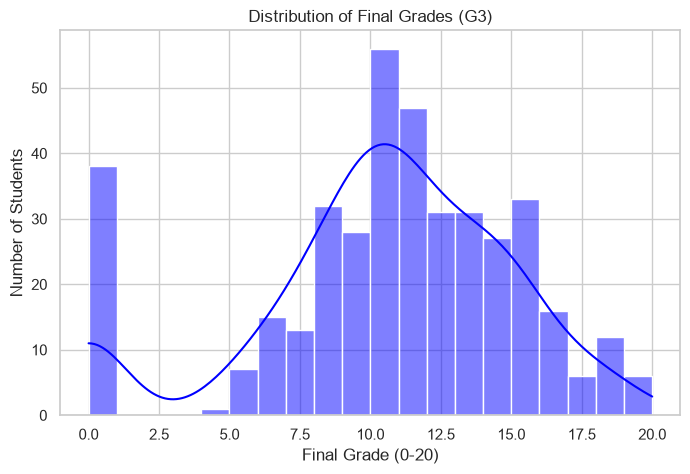

In [14]:
# Create a histogram to see how final grades are distributed
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='blue')

plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (0-20)')
plt.ylabel('Number of Students')
plt.show()

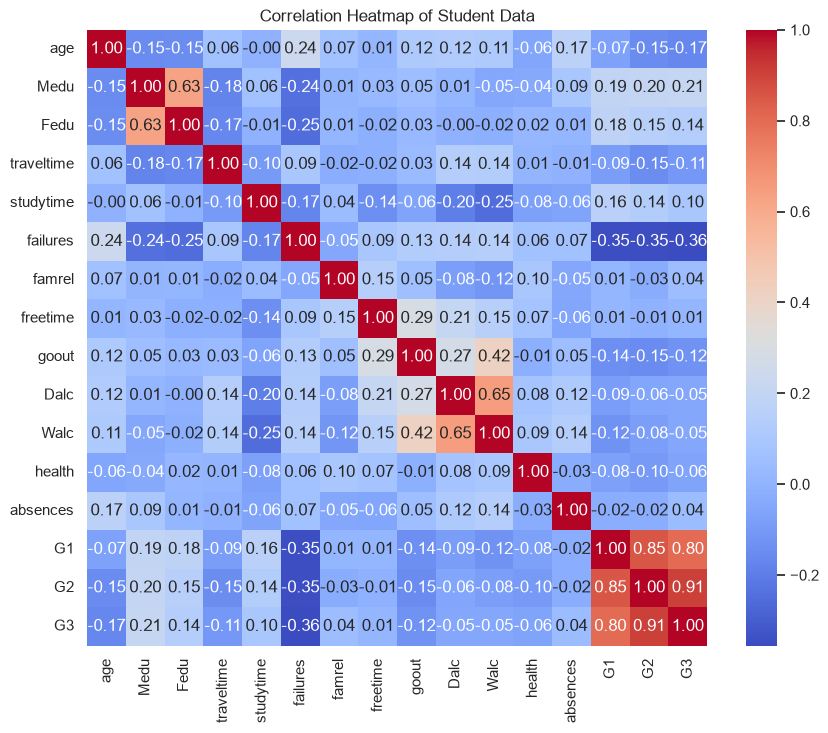

In [15]:
# Select only the columns that have numbers (ignoring text for now)
numeric_columns = df.select_dtypes(include=[np.number])

# Calculate how closely related these numbers are to each other
correlation_matrix = numeric_columns.corr()

# Draw a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Student Data')
plt.show()

In [16]:
# 1. Identify which columns contain text (pandas calls these 'object' types)
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columns being converted:\n", list(categorical_cols))

# 2. Convert them into 1s and 0s
# drop_first=True prevents redundant columns (e.g., if internet_yes=1, we don't need an internet_no column)
df_clean = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Check the transformation
print(f"\nOld dataset size: {df.shape}")
print(f"New dataset size: {df_clean.shape}")

# Look at the new, all-number dataset
df_clean.head()

Columns being converted:
 ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Old dataset size: (399, 33)
New dataset size: (399, 42)


C:\Users\priya\AppData\Local\Temp\ipykernel_428\3734906676.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [17]:
# Calculate correlations of all columns against the final grade (G3)
correlations = df_clean.corr()['G3'].sort_values(ascending=False)

print("Top 5 POSITIVE impacts on final grade:")
print(correlations.head(6)[1:]) # Skipping the very first one because G3 correlates perfectly with itself

print("\n---------------------------\n")

print("Top 5 NEGATIVE impacts on final grade:")
print(correlations.tail(5))

Top 5 POSITIVE impacts on final grade:
G2            0.905304
G1            0.802695
Medu          0.206658
higher_yes    0.180186
Fedu          0.140584
Name: G3, dtype: float64

---------------------------

Top 5 NEGATIVE impacts on final grade:
traveltime     -0.111785
romantic_yes   -0.124011
goout          -0.124362
age            -0.167627
failures       -0.355695
Name: G3, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_clean.drop(columns=['G3'])
y = df_clean['G3']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 319
Testing samples: 80


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test data
lr_preds = lr_model.predict(X_test)

# Calculate metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results:")
print(f"Mean Absolute Error (MAE): {lr_mae:.2f} grade points")
print(f"R2 Score: {lr_r2:.2f}")

Linear Regression Results:
Mean Absolute Error (MAE): 1.38 grade points
R2 Score: 0.76


In [23]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_preds = rf_model.predict(X_test)

# Calculate metrics
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Results:")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f} grade points")
print(f"R2 Score: {rf_r2:.2f}")

Random Forest Regressor Results:
Mean Absolute Error (MAE): 1.04 grade points
R2 Score: 0.86


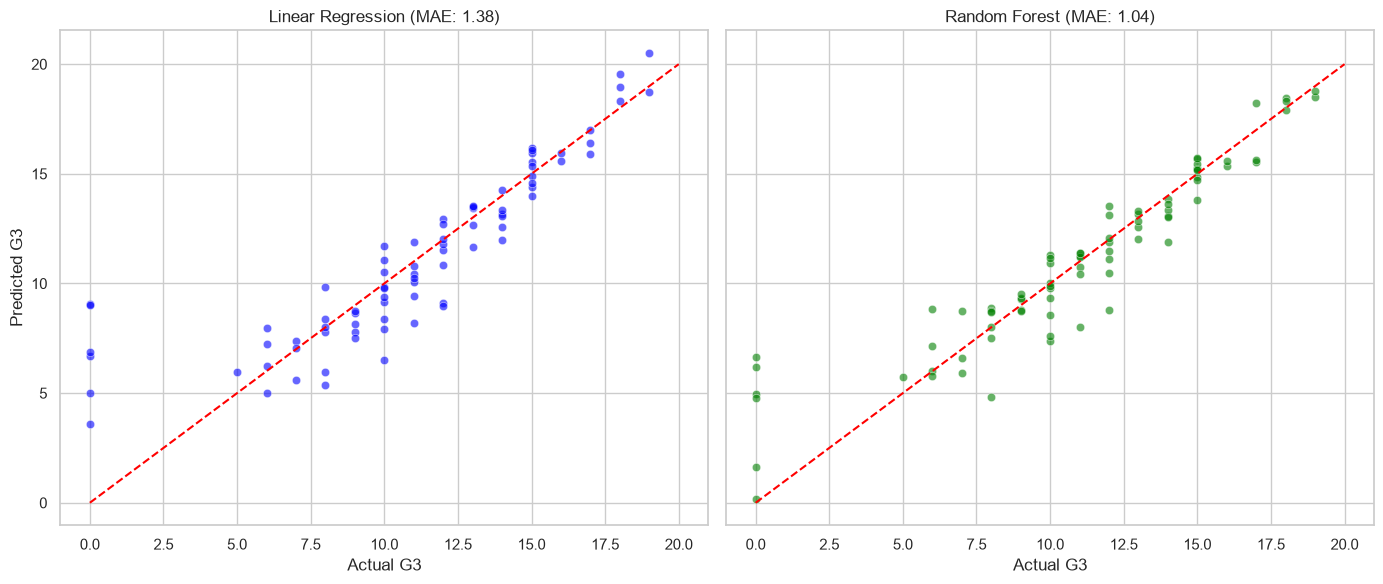

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Linear Regression Plot
sns.scatterplot(x=y_test, y=lr_preds, ax=axes[0], alpha=0.6, color='blue')
axes[0].plot([0, 20], [0, 20], '--', color='red') # Perfect prediction line
axes[0].set_title(f'Linear Regression (MAE: {lr_mae:.2f})')
axes[0].set_xlabel('Actual G3')
axes[0].set_ylabel('Predicted G3')

# Random Forest Plot
sns.scatterplot(x=y_test, y=rf_preds, ax=axes[1], alpha=0.6, color='green')
axes[1].plot([0, 20], [0, 20], '--', color='red') # Perfect prediction line
axes[1].set_title(f'Random Forest (MAE: {rf_mae:.2f})')
axes[1].set_xlabel('Actual G3')

plt.tight_layout()
plt.show()